In [1]:
import pandas as pd

df = pd.read_csv("Groceries_dataset.csv")

print(df.shape)
df.head()

(38765, 3)


,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [2]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Member_number    38765 non-null  int64 
 1   Date             38765 non-null  object
 2   itemDescription  38765 non-null  object
dtypes: int64(1), object(2)
memory usage: 908.7+ KB
None
Member_number      0
Date               0
itemDescription    0
dtype: int64


In [3]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

print(df.dtypes)
df.head()

Member_number               int64
Date               datetime64[ns]
itemDescription            object
dtype: object


,Member_number,Date,itemDescription
0,1808,2015-07-21,tropical fruit
1,2552,2015-01-05,whole milk
2,2300,2015-09-19,pip fruit
3,1187,2015-12-12,other vegetables
4,3037,2015-02-01,whole milk


In [4]:
top_items = df['itemDescription'].value_counts().head(10)

print(top_items)

itemDescription
whole milk          2502
other vegetables    1898
rolls/buns          1716
soda                1514
yogurt              1334
root vegetables     1071
tropical fruit      1032
bottled water        933
sausage              924
citrus fruit         812
Name: count, dtype: int64


Matplotlib is building the font cache; this may take a moment.


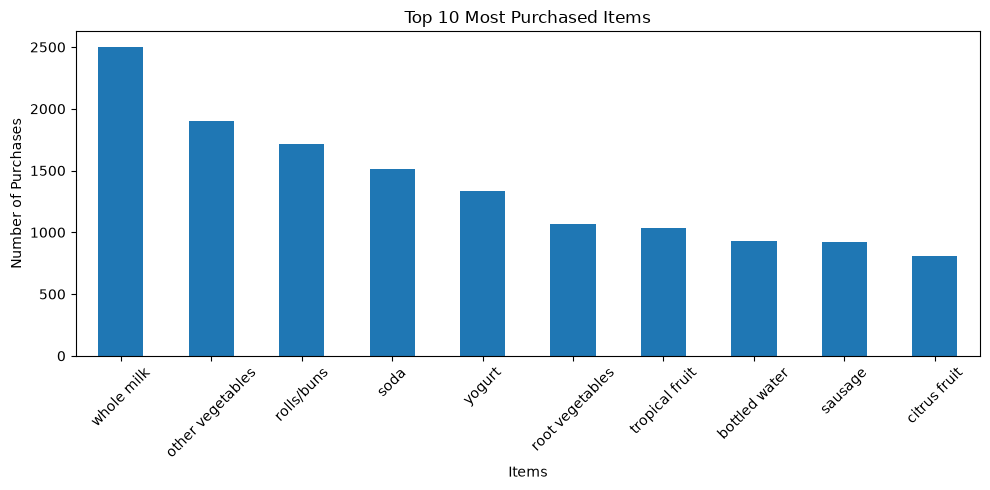

In [7]:
import matplotlib.pyplot as plt

top_items.plot(kind='bar', figsize=(10,5))

plt.title('Top 10 Most Purchased Items')
plt.xlabel('Items')
plt.ylabel('Number of Purchases')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
transactions = df.groupby(['Member_number', 'Date'])['itemDescription'].apply(list)

transactions.head()

Member_number  Date      
1000           2014-06-24                    [whole milk, pastry, salty snack]
               2015-03-15    [sausage, whole milk, semi-finished bread, yog...
               2015-05-27                           [soda, pickled vegetables]
               2015-07-24                       [canned beer, misc. beverages]
               2015-11-25                          [sausage, hygiene articles]
Name: itemDescription, dtype: object

In [10]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

basket = pd.DataFrame(te_array, columns=te.columns_)

basket.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [11]:
from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(
    basket,
    min_support=0.01,
    use_colnames=True
)

frequent_itemsets.sort_values(
    by='support',
    ascending=False
).head(10)

,support,itemsets
62,0.157923,(whole milk)
40,0.122101,(other vegetables)
46,0.110005,(rolls/buns)
52,0.097106,(soda)
63,0.085879,(yogurt)
47,0.069572,(root vegetables)
57,0.067767,(tropical fruit)
5,0.060683,(bottled water)
49,0.060349,(sausage)
15,0.053131,(citrus fruit)


In [13]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1.0
)

rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values(
    by='lift',
    ascending=False
).head(10)

,antecedents,consequents,support,confidence,lift


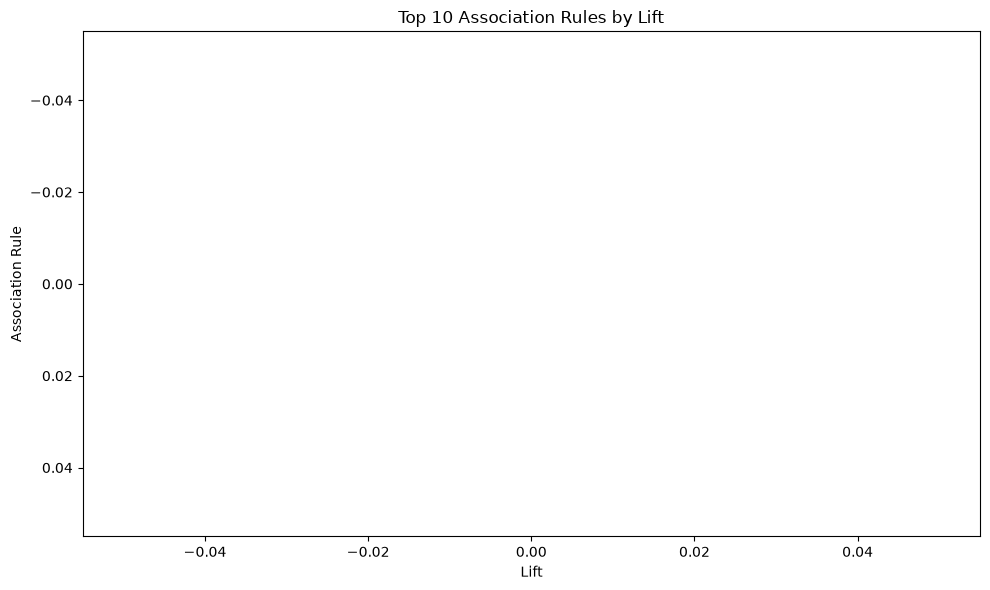

In [14]:
top_rules = rules.sort_values(
    by='lift',
    ascending=False
).head(10)

labels = [
    f"{', '.join(list(a))} → {', '.join(list(c))}"
    for a, c in zip(top_rules['antecedents'], top_rules['consequents'])
]

plt.figure(figsize=(10, 6))
plt.barh(labels, top_rules['lift'])
plt.xlabel('Lift')
plt.ylabel('Association Rule')
plt.title('Top 10 Association Rules by Lift')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [15]:
print("Frequent itemsets:", len(frequent_itemsets))
print("Association rules:", len(rules))

Frequent itemsets: 69
Association rules: 0


In [16]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.1
)

rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values(
    by='lift',
    ascending=False
).head(10)

,antecedents,consequents,support,confidence,lift
3,(yogurt),(whole milk),0.011161,0.129961,0.822940
1,(rolls/buns),(whole milk),0.013968,0.126974,0.804028
0,(other vegetables),(whole milk),0.014837,0.121511,0.769430
2,(soda),(whole milk),0.011629,0.119752,0.758296


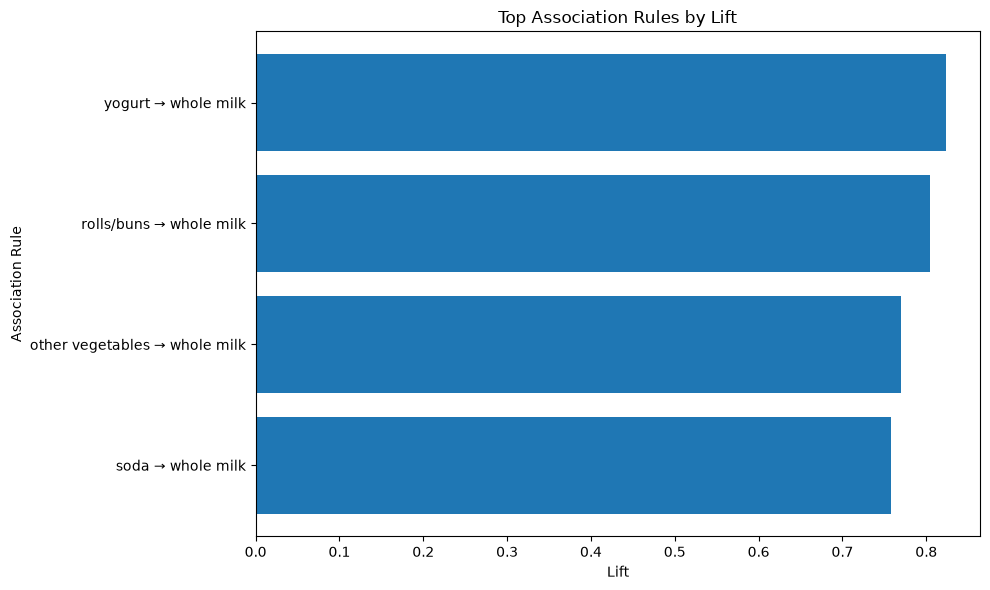

In [17]:
top_rules = rules.sort_values(
    by='lift',
    ascending=False
).head(10)

labels = [
    f"{', '.join(list(a))} → {', '.join(list(c))}"
    for a, c in zip(top_rules['antecedents'], top_rules['consequents'])
]

plt.figure(figsize=(10, 6))
plt.barh(labels, top_rules['lift'])
plt.xlabel('Lift')
plt.ylabel('Association Rule')
plt.title('Top Association Rules by Lift')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Business Insights

- Whole milk is the most frequently purchased product in the dataset.
- Other vegetables, rolls/buns, soda, and yogurt are also among the frequently purchased items.
- Association rules were generated using the Apriori algorithm.
- Yogurt → whole milk has the highest lift among the generated rules.
- The generated rules can help identify product purchasing patterns and support cross-selling strategies.

## Conclusion

Market Basket Analysis was performed on grocery transaction data using the Apriori algorithm. The analysis identified frequently purchased products and generated association rules based on support, confidence, and lift. These insights can help businesses understand customer purchasing patterns and improve product placement and cross-selling decisions.